In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from tools.eda import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, accuracy_score, roc_auc_score

In [17]:
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [18]:
def get_numerical_and_categorical_features(
    df: pd.DataFrame,
    ignore_columns: list = None
) -> tuple[list, list]:
    """
    Identify numerical and categorical features in a DataFrame.

    Args:
        df: Pandas DataFrame to analyze.
        ignore_columns: List of column names to exclude from the analysis.

    Returns:
        tuple: (numerical_features, categorical_features)
    """
    if ignore_columns is None:
        ignore_columns = []
    
    # Get all numerical and categorical features
    num_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
    cat_features = df.select_dtypes(include=["object", "category"]).columns.tolist()
    
    # Filter out ignored columns
    num_features = [col for col in num_features if col not in ignore_columns]
    cat_features = [col for col in cat_features if col not in ignore_columns]
    
    return num_features, cat_features

## Data cleaning

In [19]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [20]:
df['SeniorCitizen'] = df['SeniorCitizen'].astype(bool)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [21]:
#df['gender'] = df['gender'].astype('category')
#df['Partner'] = df['Partner'].astype('category')
#df['Dependents'] = df['Dependents'].astype('category')
#df['PhoneService'] = df['PhoneService'].astype('category')
#df['MultipleLines'] = df['MultipleLines'].astype('category')
#df['InternetService'] = df['InternetService'].astype('category')
#df['OnlineSecurity'] = df['OnlineSecurity'].astype('category')
#df['OnlineBackup'] = df['OnlineBackup'].astype('category')
#df['DeviceProtection'] = df['DeviceProtection'].astype('category')
#df['TechSupport'] = df['TechSupport'].astype('category')
#df['StreamingTV'] = df['StreamingTV'].astype('category')
#df['StreamingMovies'] = df['StreamingMovies'].astype('category')
#df['Contract'] = df['Contract'].astype('category')
#df['PaperlessBilling'] = df['PaperlessBilling'].astype('category')
#df['PaymentMethod'] = df['PaymentMethod'].astype('category')

In [22]:
TARGET = 'Churn'
num_features, cat_features = get_numerical_and_categorical_features(
    df,
    ignore_columns=["customerID", "Churn"]
)

/var/folders/4t/35nfm0b159g9bz03rt5zzm_h0000gn/T/ipykernel_51788/2352443174.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = df.select_dtypes(include=["object", "category"]).columns.tolist()


## Feature engineering

In [23]:
#df['AverageCharges'] = df['TotalCharges'] / (df['tenure'] + 1e-5)
#df['HasPhoneService'] = df['PhoneService'].apply(lambda x: 1 if x == 'Yes' else 0)
#df['HasInternetService'] = df['InternetService'].apply(lambda x: 0 if x == 'No' else 1)
#df['TenureGroup'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 60, np.inf], labels=['0-12', '13-24', '25-48', '49-60', '60+'])
#df['IsIndividual'] = df.apply(lambda row: 1 if row['Partner'] == 'No' and row['Dependents'] == 'No' else 0, axis=1)
df["bi_Contract_Internet"] = df["Contract"] + "__" + df["InternetService"]
df["bi_PaymentMethod_Internet"] = df["PaymentMethod"] + "__" + df["InternetService"]
df["bi_Contract_PaymentMethod"] = df["Contract"] + "__" + df["PaymentMethod"]
#df["HasTechSupport"] = df["TechSupport"].apply(lambda x: 1 if x == 'Yes' else 0)
#df["HasMonthToMonthContract"] = df["Contract"].apply(lambda x: 1 if x == 'Month-to-month' else 0)


In [24]:
num_features, cat_features = get_numerical_and_categorical_features(
    df,
    ignore_columns=["customerID", "Churn"]
)

/var/folders/4t/35nfm0b159g9bz03rt5zzm_h0000gn/T/ipykernel_51788/2352443174.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = df.select_dtypes(include=["object", "category"]).columns.tolist()


## Split data

In [25]:
X = df[cat_features + num_features]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Logistic regression (baseline model)

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])
    
model_pipeline.fit(
    X_train,
    y_train,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [27]:
y_pred = model_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(roc_auc_score(y_test, model_pipeline.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409

0.8190205819730305
0.8620040473257632


## Random Forest

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=1000 , oob_score = True, n_jobs = -1,
        random_state =50,
        max_leaf_nodes = 30
    ))
])
    
model_pipeline.fit(
    X_train,
    y_train,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [29]:
y_pred = model_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(roc_auc_score(y_test, model_pipeline.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.70      0.52      0.60       373

    accuracy                           0.82      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.81      0.82      0.81      1409

0.815471965933286
0.8619820509900938


                                                        feature  importance
          cat__bi_Contract_Internet_Month-to-month__Fiber optic    0.118659
                                                    num__tenure    0.108728
                                   cat__Contract_Month-to-month    0.100295
                                              num__TotalCharges    0.078106
cat__bi_Contract_PaymentMethod_Month-to-month__Electronic check    0.070946
                                         cat__OnlineSecurity_No    0.064495
                                            cat__TechSupport_No    0.052226
   cat__bi_PaymentMethod_Internet_Electronic check__Fiber optic    0.043606
                               cat__InternetService_Fiber optic    0.034857
                                            num__MonthlyCharges    0.034728
                                         cat__Contract_Two year    0.033872
                            cat__PaymentMethod_Electronic check    0.025654
            

/var/folders/4t/35nfm0b159g9bz03rt5zzm_h0000gn/T/ipykernel_51788/1797903013.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


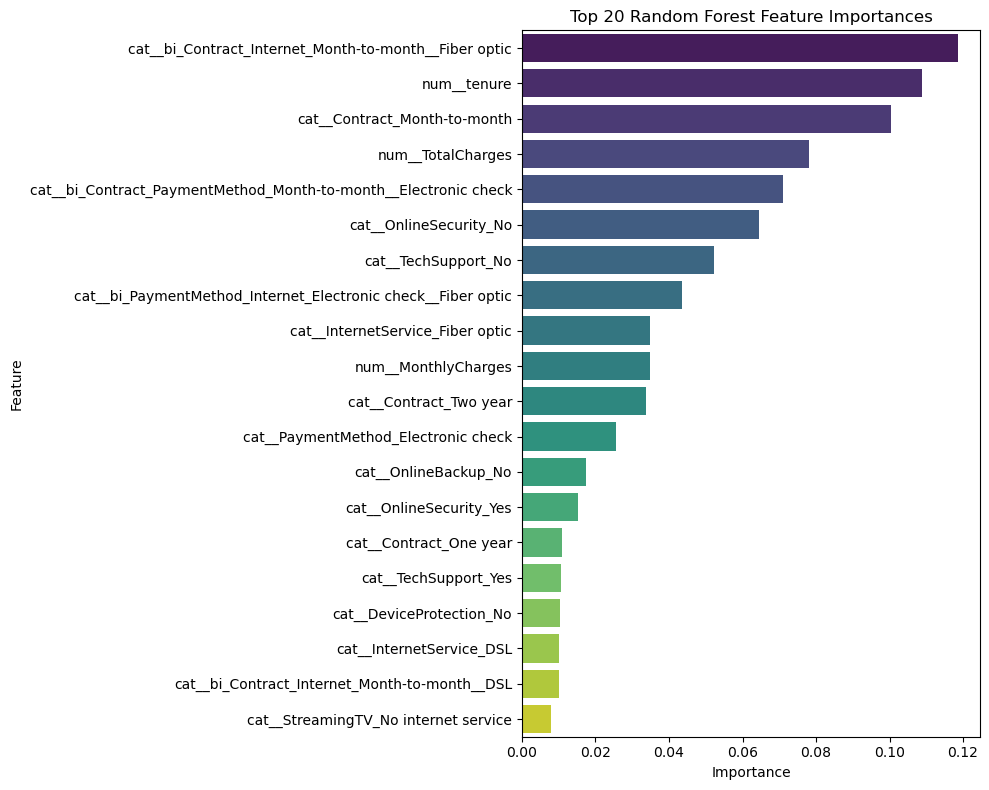

In [30]:
# Extract feature names after preprocessing and compute random forest importances
preprocessor = model_pipeline.named_steps['preprocessor']
classifier = model_pipeline.named_steps['classifier']

if hasattr(preprocessor, 'get_feature_names_out'):
    feature_names = preprocessor.get_feature_names_out()
else:
    # Fallback for older scikit-learn versions
    num_names = num_features
    cat_names = preprocessor.named_transformers_['cat'].get_feature_names(cat_features)
    feature_names = np.concatenate([num_names, cat_names])

feature_importances = classifier.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

print(feature_importance_df.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance_df.head(20),
    x='importance',
    y='feature',
    palette='viridis'
)
plt.title('Top 20 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()